# Librerías y configuración inicial
Importamos las librerías necesarias para el entrenamiento del modelo XGBoost y el cálculo de métricas de desempeño.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve

plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'figure.dpi': 150})

# Carga de datos preprocesados
Cargamos los conjuntos de entrenamiento y prueba que fueron generados y exportados en la fase de preprocesamiento.

In [8]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')

y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f"Dimensiones de entrenamiento: X_train {X_train.shape}, y_train {y_train.shape}")
print(f"Dimensiones de prueba: X_test {X_test.shape}, y_test {y_test.shape}")

X_train.head()

Dimensiones de entrenamiento: X_train (954, 31), y_train (954,)
Dimensiones de prueba: X_test (185, 31), y_test (185,)


,age_first_funding_year,age_last_funding_year,age_first_milestone_year,age_last_milestone_year,relationships,funding_rounds,funding_total_usd,milestones,is_CA,is_NY,...,is_consulting,is_othercategory,has_VC,has_angel,has_roundA,has_roundB,has_roundC,has_roundD,avg_participants,is_top500
0,-0.153973,-0.222365,0.226415,1.029781,16,2,-0.050779,4,0,0,...,0,0,0,0,1,1,0,0,-0.182050,1
1,-0.518422,-0.456339,0.120081,-0.030764,5,2,-0.060703,2,0,0,...,0,0,0,0,1,1,0,0,-0.447537,1
2,1.302783,0.499797,-0.859479,-1.181894,5,1,0.010183,0,1,0,...,0,1,0,0,0,0,1,0,1.676357,1
3,2.125838,1.192506,1.464049,0.849452,6,1,-0.060703,1,1,0,...,0,1,0,0,0,0,0,1,1.676357,1
4,1.142989,0.365310,0.718019,0.571405,7,1,-0.107960,2,1,0,...,0,0,0,0,1,0,0,0,-0.978510,0


## Consideraciones del problema

El objetivo es predecir si una startup será adquirida (clase 1) o cerrará (clase 0), 
desde la perspectiva de un inversionista que evalúa riesgo.

- **Falso positivo (más costoso):** predecir adquisición cuando la startup quiebra → pérdida de capital.
- **Falso negativo (menos costoso):** predecir cierre cuando la startup es adquirida → oportunidad perdida.

Por esto, además de AUC-ROC priorizaremos **precisión en la clase positiva** y 
ajustaremos el umbral de decisión si es necesario.

## Modelo baseline: Regresión Logística

Entrenamos una Regresión Logística como punto de referencia antes de probar XGBoost.
Esto nos da un piso de desempeño contra el cual comparar modelos más complejos.

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold

# 5-fold estratificado para mantener proporción de clases en cada fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Baseline simple
baseline = LogisticRegression(max_iter=1000, random_state=42)

# Validación cruzada en train
baseline_cv_scores = cross_val_score(baseline, X_train, y_train, 
                                      cv=cv, scoring='roc_auc')

print(f"Baseline (LogReg) - AUC-ROC en CV:")
print(f"  Media: {baseline_cv_scores.mean():.4f}")
print(f"  Std:   {baseline_cv_scores.std():.4f}")
print(f"  Folds: {[f'{s:.4f}' for s in baseline_cv_scores]}")

# Entrenamos sobre todo el train y evaluamos en test
baseline.fit(X_train, y_train)
baseline_test_auc = roc_auc_score(y_test, baseline.predict_proba(X_test)[:, 1])
print(f"\nBaseline (LogReg) - AUC-ROC en test: {baseline_test_auc:.4f}")

Baseline (LogReg) - AUC-ROC en CV:
  Media: 0.8619
  Std:   0.0220
  Folds: ['0.8203', '0.8774', '0.8596', '0.8808', '0.8715']

Baseline (LogReg) - AUC-ROC en test: 0.7927


## Modelo principal: XGBoost

Entrenamos XGBoost con hiperparámetros conservadores, eligidos pensando en el tamaño 
del dataset (954 muestras de train, 31 features). Una profundidad moderada y 
regularización ayudan a evitar overfitting en un dataset relativamente pequeño.

In [ ]:
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    eval_metric='logloss'
)

# Validación cruzada en train
xgb_cv_scores = cross_val_score(xgb_model, X_train, y_train, 
                                 cv=cv, scoring='roc_auc')

print(f"XGBoost base - AUC-ROC en CV:")
print(f" Media: {xgb_cv_scores.mean():.4f}")
print(f" Std: {xgb_cv_scores.std():.4f}")
print(f" Folds: {[f'{s:.4f}' for s in xgb_cv_scores]}")

# Entrenamos sobre todo el train y evaluamos en test
xgb_model.fit(X_train, y_train)
xgb_test_auc = roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:, 1])
print(f"\nXGBoost base - AUC-ROC en test: {xgb_test_auc:.4f}")

# Comparación rápida con baseline
print(f"\nComparación")
print(f"Baseline (LogReg) test: {baseline_test_auc:.4f}")
print(f"XGBoost base test: {xgb_test_auc:.4f}")
print(f"Mejora: {(xgb_test_auc - baseline_test_auc)*100:+.2f} puntos porcentuales")

XGBoost base - AUC-ROC en CV:
  Media: 0.8781
  Std:   0.0184
  Folds: ['0.8558', '0.9037', '0.8739', '0.8624', '0.8946']

XGBoost base - AUC-ROC en test: 0.8241

--- Comparación ---
Baseline (LogReg) test: 0.7927
XGBoost base test:      0.8241
Mejora: +3.14 puntos porcentuales


## Evaluación detallada en el conjunto de test

Métricas completas, matriz de confusión y curvas ROC/Precision-Recall.

=== Métricas en Test ===
AUC-ROC:   0.8241
Accuracy:  0.7784
Precision: 0.8211
Recall:    0.8417
F1:        0.8313

=== Classification Report ===
              precision    recall  f1-score   support

      Closed       0.69      0.66      0.68        65
    Acquired       0.82      0.84      0.83       120

    accuracy                           0.78       185
   macro avg       0.76      0.75      0.75       185
weighted avg       0.78      0.78      0.78       185



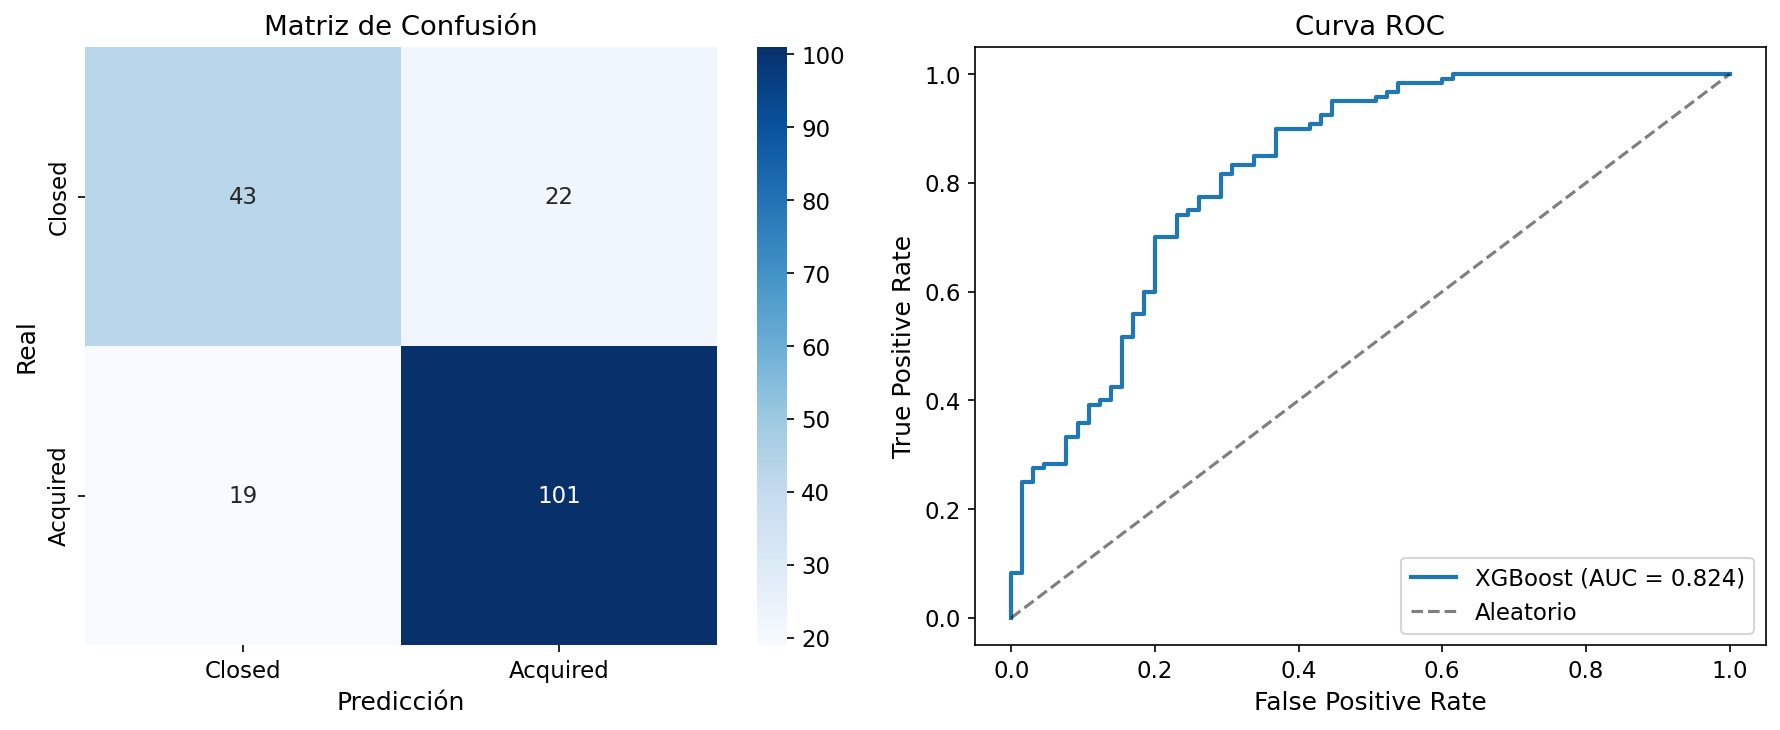

In [15]:
# Predicciones
y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

# Métricas principales
print("=== Métricas en Test ===")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_proba):.4f}")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1:        {f1_score(y_test, y_pred):.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Closed', 'Acquired']))

# Matriz de confusión y ROC
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Closed', 'Acquired'],
            yticklabels=['Closed', 'Acquired'], ax=axes[0])
axes[0].set_title('Matriz de Confusión')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicción')

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, label=f'XGBoost (AUC = {xgb_test_auc:.3f})', linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', label='Aleatorio', alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curva ROC')
axes[1].legend()

plt.tight_layout()
plt.show()

In [17]:
import os
import joblib

os.makedirs('../models', exist_ok=True)
joblib.dump(xgb_model, '../models/xgboost_model.pkl')
print("Modelo guardado en ../models/xgboost_model.pkl")

Modelo guardado en ../models/xgboost_model.pkl
